In [1]:
import sys
sys.path.append("../data")
from acoupipe_extensions import VariableArrayConfig, random_positions, VogelHansen

from acoupipe.datasets.synthetic import DatasetSynthetic

import numpy as np
import matplotlib.pyplot as plt

/home/zaid/.conda/envs/thesis/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [2]:
from scipy import optimize, special
from scipy.integrate import quad

def VogelHansenNew(min_num_mics, max_num_mics, generator):

    #uniformly distribute H and M
    M = generator.integers(min_num_mics, max_num_mics + 1) 
    H = generator.uniform(-1,4)

    V = 5
    

    r_max=0.5


    def F(r):
        if H<0:
            return 1/special.iv(0,np.pi*H*np.sqrt(1+0j-r*r))
        
        return special.iv(0,np.pi*H*np.sqrt(1+0j-r*r))
    
    def Freal(r):
        return F(r).real
    
    FI = quad(Freal,0,1)[0]  

    def Froot(r):
        A = FI/(M*F(r))
        r0 = np.sqrt(np.cumsum(A)).real
        return (r-r0)
    
    rz = optimize.leastsq(Froot,np.zeros(M)/M+0.01)
    rz = rz[0]
    rm = rz * r_max/rz.max() 
    n = np.arange(M)+1
    theta = np.pi*n*(1+np.sqrt(V))
    xyz = np.zeros((3,M),dtype=np.double)
    xyz[0] = rm*np.cos(theta)
    xyz[1] = rm*np.sin(theta)

    # Centering
    xyz[0] -= np.mean(xyz[0])
    xyz[1] -= np.mean(xyz[1])

    #Normalizing 
    aperture = np.max(pdist(xyz[:2].T)) #Aperture in acoupipe is defined as the maximum pairwise distance between microphones
    xyz[:2] /= aperture

    return xyz


def random_positions(min_num_mics, max_num_mics, generator):
    """
    Generate a random centered planar microphone array with normalized aperture.

    Parameters
    ----------
    min_num_mics : int
        Minimum number of microphones to sample.
    max_num_mics : int
        Maximum number of microphones to sample.
    generator : np.random.Generator
        NumPy random number generator for reproducible sampling.

    Returns
    -------
    np.ndarray
        Microphone positions with shape (3, N), where N is the number of
        microphones.
    """

    # --- sample number of microphones ---
    n = generator.integers(min_num_mics, max_num_mics + 1)

    # --- sample positions uniformly over a disk ---
    # sqrt ensures uniform spatial density in polar coordinates
    r = 0.5 * np.sqrt(generator.random(n))
    theta = 2 * np.pi * generator.random(n)

    x = r * np.cos(theta)
    y = r * np.sin(theta)
    z = np.zeros(n)

    # --- assemble planar coordinates ---
    positions = np.column_stack((x, y, z))  # shape: (N, 3)

    # --- center array at the origin (translation invariance) ---
    positions -= positions.mean(axis=0)

    # --- normalize array aperture (scale invariance) ---
    # max pairwise distance equals 1 after normalization
    positions /= np.max(pdist(positions))

    # --- return in AcouPipe-compatible shape (3, N) ---
    return positions.T   

  0%|          | 0/20 [00:00<?, ?it/s]

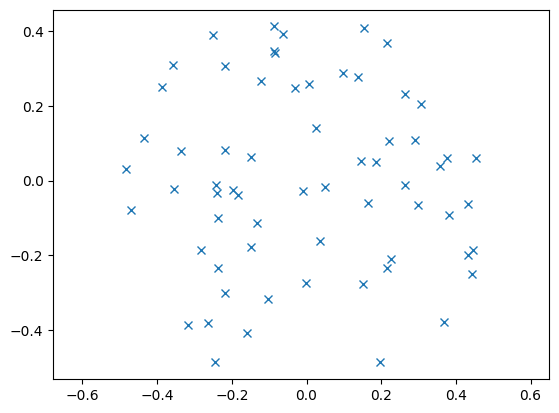

  5%|▌         | 1/20 [00:00<00:06,  2.96it/s]

torch.Size([3, 64])


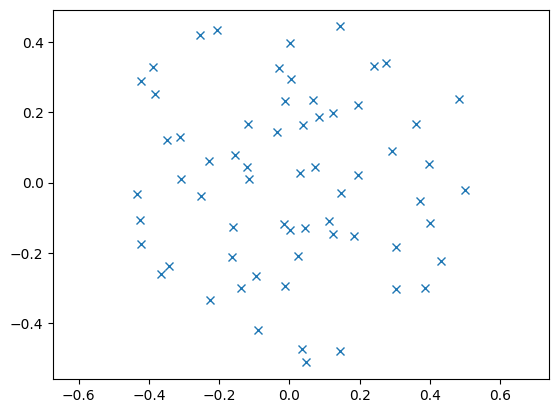

 10%|█         | 2/20 [00:00<00:04,  3.98it/s]

torch.Size([3, 64])


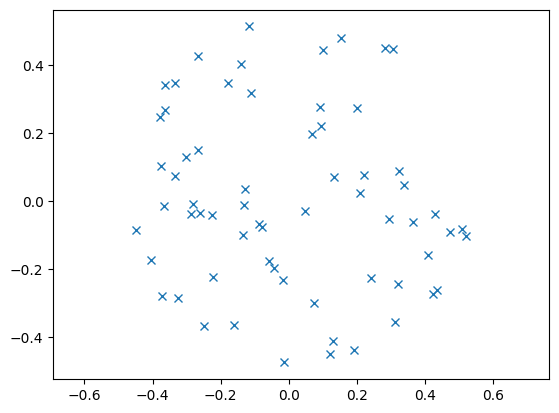

 15%|█▌        | 3/20 [00:00<00:03,  4.46it/s]

torch.Size([3, 64])


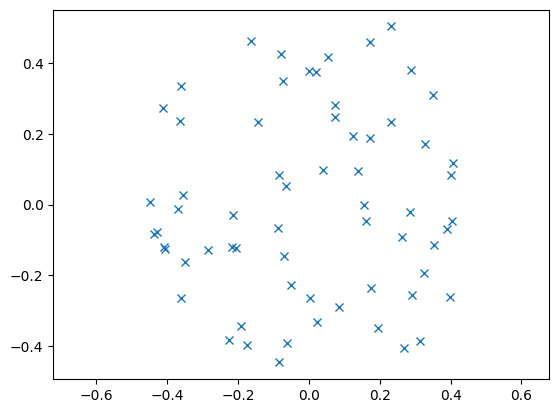

 20%|██        | 4/20 [00:00<00:03,  4.91it/s]

torch.Size([3, 64])


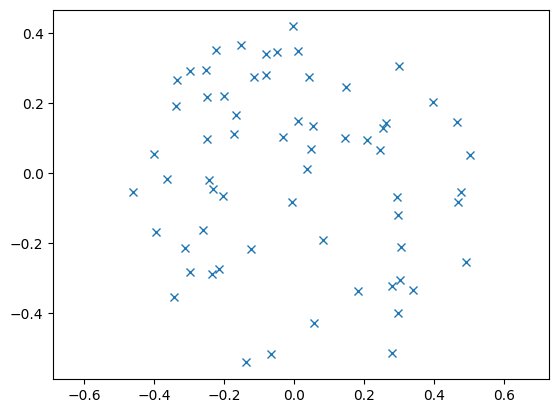

 25%|██▌       | 5/20 [00:01<00:02,  5.25it/s]

torch.Size([3, 64])


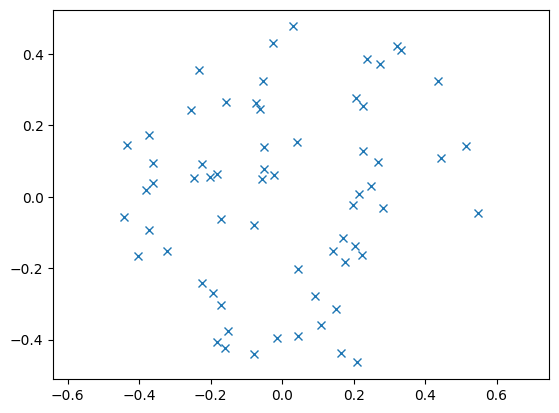

 30%|███       | 6/20 [00:01<00:02,  5.40it/s]

torch.Size([3, 64])


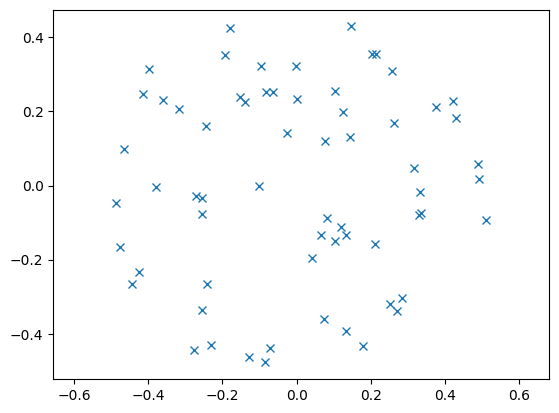

 35%|███▌      | 7/20 [00:01<00:02,  5.39it/s]

torch.Size([3, 64])


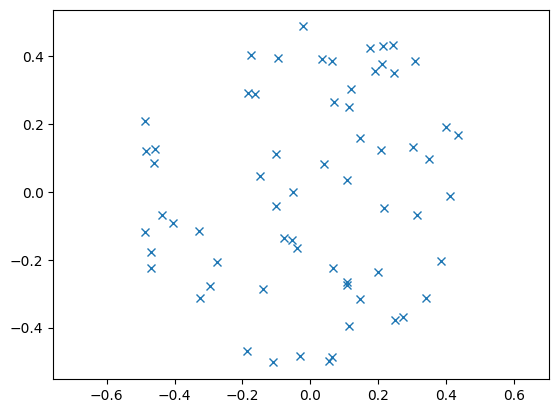

 40%|████      | 8/20 [00:01<00:02,  5.65it/s]

torch.Size([3, 64])


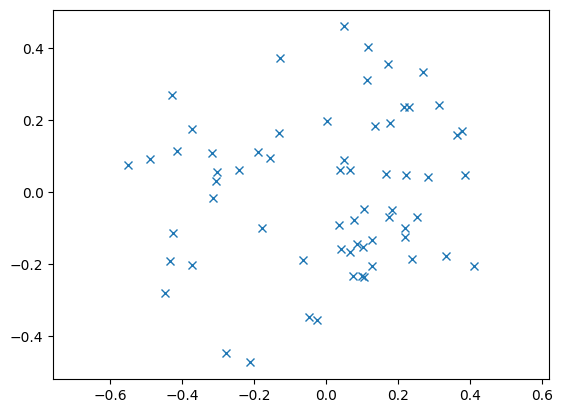

 45%|████▌     | 9/20 [00:01<00:01,  5.86it/s]

torch.Size([3, 64])


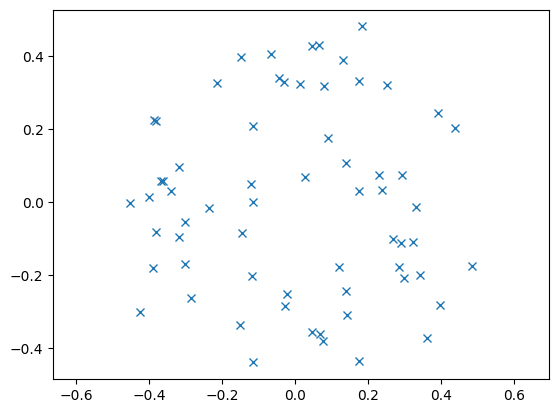

 50%|█████     | 10/20 [00:01<00:01,  5.83it/s]

torch.Size([3, 64])


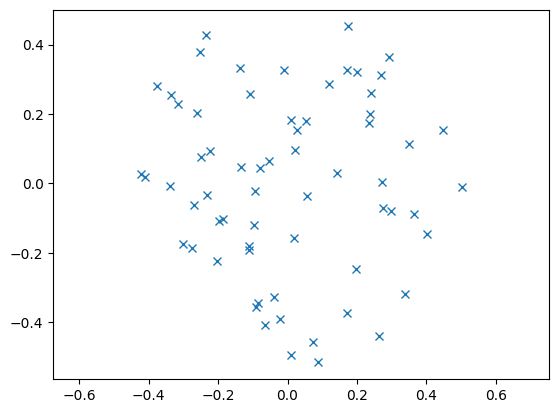

 55%|█████▌    | 11/20 [00:02<00:01,  5.86it/s]

torch.Size([3, 64])


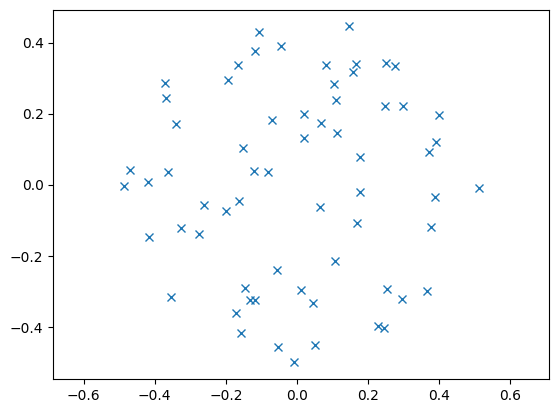

 60%|██████    | 12/20 [00:02<00:01,  6.10it/s]

torch.Size([3, 64])


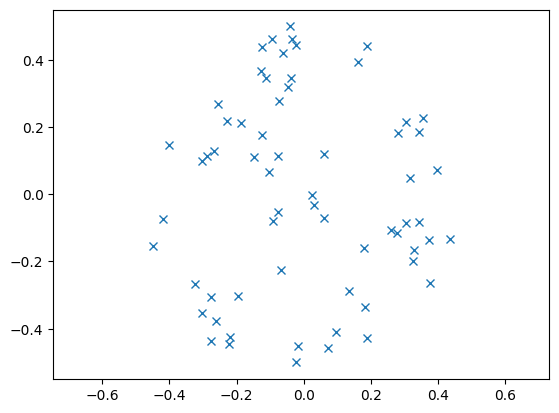

 65%|██████▌   | 13/20 [00:02<00:01,  5.91it/s]

torch.Size([3, 64])


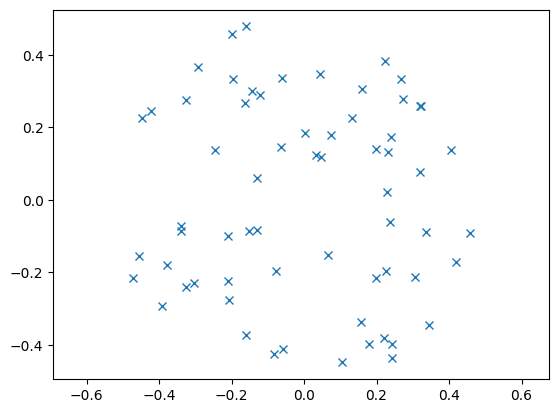

 70%|███████   | 14/20 [00:02<00:01,  5.84it/s]

torch.Size([3, 64])


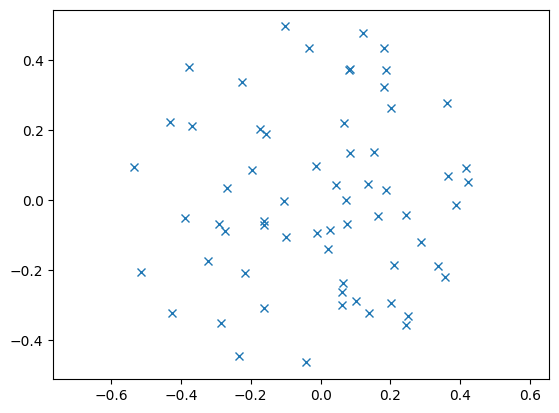

 75%|███████▌  | 15/20 [00:02<00:00,  5.81it/s]

torch.Size([3, 64])


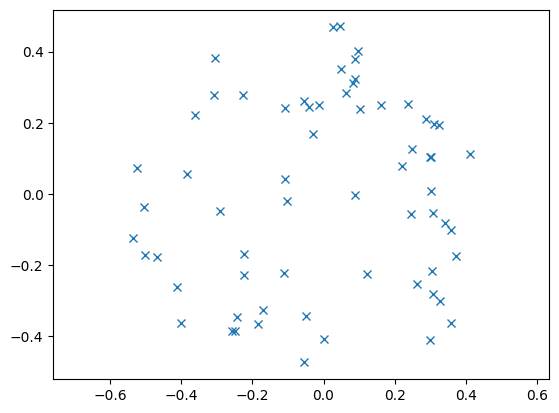

 80%|████████  | 16/20 [00:02<00:00,  5.86it/s]

torch.Size([3, 64])


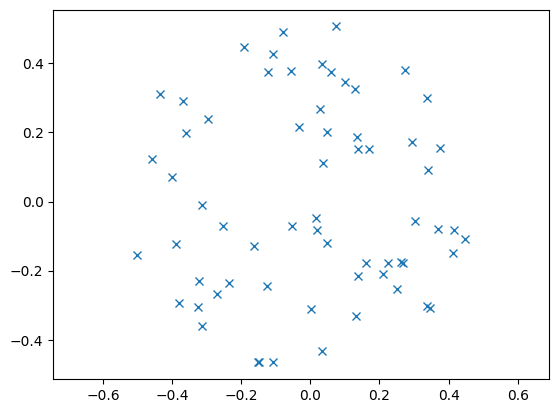

 85%|████████▌ | 17/20 [00:03<00:00,  6.08it/s]

torch.Size([3, 64])


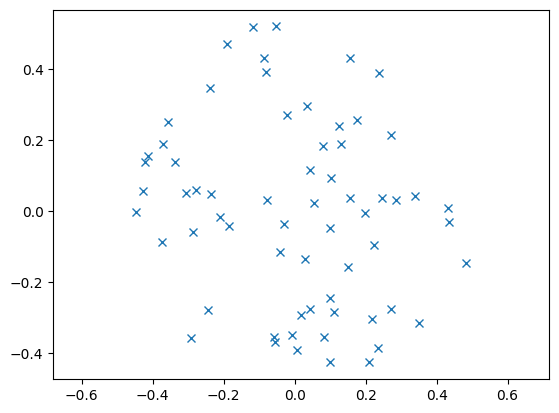

 90%|█████████ | 18/20 [00:03<00:00,  3.77it/s]

torch.Size([3, 64])


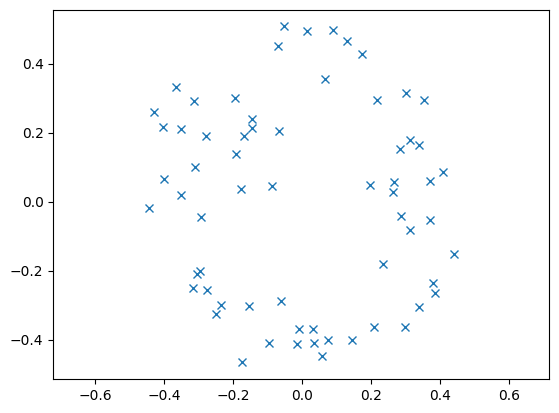

 95%|█████████▌| 19/20 [00:03<00:00,  4.39it/s]

torch.Size([3, 64])


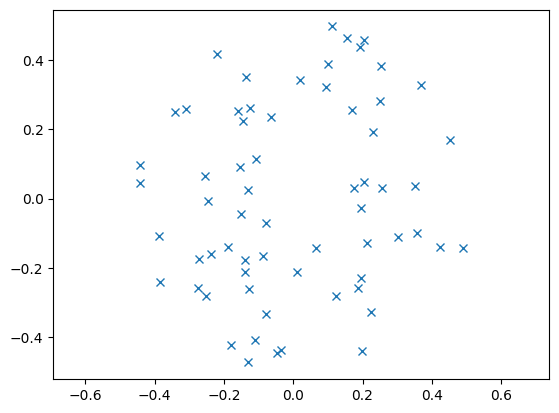

100%|██████████| 20/20 [00:03<00:00,  5.18it/s]

torch.Size([3, 64])


In [3]:
import torch
from scipy.spatial.distance import pdist


test_generator = np.random.default_rng(seed=20006)
config = VariableArrayConfig(mpos_fn=random_positions, mode="analytic", mic_sig_noise=False, generator=test_generator, min_nsources=1, max_nsources=4, min_num_mics=64, max_num_mics=64)

dataset = DatasetSynthetic(config=config)

dataset_generator = dataset.generate(
    #features=["loc","source_strength_analytic"], # choose the features to extract
    features = ["cartesian_coordinates"], # choose the features to extract
    f=[1000], # choose the frequencies to extract
    split='training', # choose the split of the dataset
    size=20, # choose the size of the dataset
    )


for data in dataset_generator:
    coords = torch.tensor(data["cartesian_coordinates"])
    plt.plot(coords[0,:], coords[1,:], "x")
    plt.axis('equal')
    plt.show()

    print(coords.shape)
        
        
        
        

In [4]:
 #coords = torch.tensor(data["cartesian_coordinates"])
        #plt.plot(coords[0,:], coords[1,:], "x")
        #plt.axis('equal')
        #plt.show()

        #print(coords.shape)

        #csm = torch.tensor(data["csm"])
        #print(csm)
        #print(data["idx"], "\n")
        #array = dataset.config.micgeom_sampler.target
        #coords = array.pos_total
        #print(array.center)
        #print(array.aperture)
        #plt.scatter(coords[0], coords[1])
        #plt.axis('equal')
        #plt.show()